In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import nn4n

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Generate experience vectors (trial, time, channel) 

In [2]:
ntrial, ntime, nchannel = 256, 200, 100
# EVs = np.zeros((ntrial, ntime, nchannel))
mask_EVs = np.zeros((ntrial, ntime, nchannel))

Generate 100 temporal hannels sampling source

In [6]:
# Generate 100 smooth temporal series (T=500, n=100) sampling source
from scipy.ndimage import gaussian_filter1d
sampleT = 500
smooth_sigma = 2
lower, upper = 1, 5
raw_series = np.random.uniform(low=lower, high=upper, size=(nchannel, sampleT))

# Apply Gaussian smoothing to each series
smooth_series = np.array([gaussian_filter1d(ts, sigma=smooth_sigma) for ts in raw_series])

print(smooth_series.shape)  # (channel = 100, sample time = 1000)

(100, 500)


Text(0.5, 0, 'Time Steps')

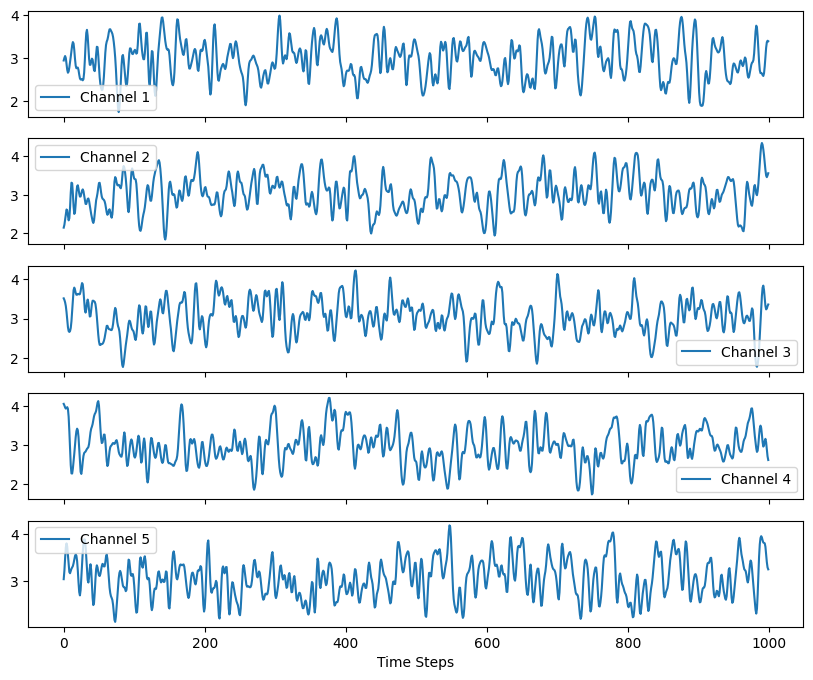

In [5]:
# Plot a few example channels
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
for i in range(5):
    axes[i].plot(smooth_series[i], label=f'Channel {i+1}')
    axes[i].legend()
plt.xlabel('Time Steps')

Generate random X, Y, Z sampling source

In [5]:
events_length = 5
sampleN = 1000

Z_length = np.random.normal(loc=100, scale=2, size=sampleN).astype(int)

X_start = np.random.randint(0, sampleT-events_length, size=sampleN)
Y_start = np.random.randint(0, sampleT-events_length, size=sampleN)

# x_start = np.random.randint(0, ntime/4-events_length, size=sampleN)
x_start = np.random.normal(loc=25, scale=1, size=sampleN).astype(int)
y_start = x_start + Z_length

In [6]:
# Sample trials from X, Y, Z
np.random.seed(42)
trial_idx = np.random.randint(0, sampleN, size=ntrial)
for i, trial in enumerate(trial_idx):
    X_s, Y_s = X_start[trial], Y_start[trial]
    x_s, y_s = x_start[trial], y_start[trial]

    # EVs[i, x_s:x_s+events_length, :] += smooth_series[:, X_s:X_s+events_length].T
    # EVs[i, y_s:y_s+events_length, :] += smooth_series[:, Y_s:Y_s+events_length].T
    
    mask_EVs[i, x_s:x_s+events_length, :] += smooth_series[:, X_s:X_s+events_length].T
    # mask_EVs[i, y_s:y_s+events_length, :] += smooth_series[:, Y_s:Y_s+events_length].T
    
    # Add some noise
    mask_EVs[i, :, :] = mask_EVs[i, :, :] + np.random.normal(loc=0.3, scale=0.3, size=(ntime, nchannel))
    # # Smooth the noise
    # for ch in range(nchannel):
    #     EVs[i, :, ch] = gaussian_filter1d(EVs[i, :, ch], sigma=1)

In [ ]:
# fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
# for i in range(3):
#     axes[i].imshow(mask_EVs[i].T, aspect='auto', cmap='hot', interpolation='nearest')
#     axes[i].set_ylabel('Channels')
# plt.xlabel('Time Steps')
# plt.tight_layout()
# plt.show()

In [7]:
EVs = mask_EVs.copy()
for i, trial in enumerate(trial_idx):
    X_s, Y_s = X_start[trial], Y_start[trial]
    x_s, y_s = x_start[trial], y_start[trial]

    # EVs[i, x_s:x_s+events_length, :] += smooth_series[:, X_s:X_s+events_length].T
    EVs[i, y_s:y_s+events_length, :] += smooth_series[:, Y_s:Y_s+events_length].T

In [8]:
# Gaussian smooth the EVs and mask_EVs
for i in range(ntrial):
    EVs[i] = gaussian_filter1d(EVs[i], sigma=2, axis=0)
    mask_EVs[i] = gaussian_filter1d(mask_EVs[i], sigma=2, axis=0)

In [9]:
# Mask EVs
decay_length = 5
for i in range(ntrial):
    mask_EVs[i, x_start[trial_idx[i]]+events_length+decay_length:, :] = 0

In [ ]:
load_data_type = '2TS_trial'
load_dir = f'../../data/'
data = np.load(f'{load_dir}/{load_data_type}.npy', allow_pickle=True).item()

inputs = torch.tensor(data[f'test_inputs'], dtype=torch.float32).to(device)
labels = torch.tensor(data[f'test_labels'], dtype=torch.float32).to(device)
outputs = torch.tensor(data[f'test_outputs_512'], dtype=torch.float32).to(device)

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
for i in range(5):
    axes[i].imshow(inputs[i].T.cpu().detach().numpy(), aspect='auto', cmap='hot', interpolation='nearest')
    axes[i].set_ylabel('Channels')
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
for i in range(5):
    axes[i].imshow(outputs[i].T.cpu().detach().numpy(), aspect='auto', cmap='hot', interpolation='nearest')
    axes[i].set_ylabel('Channels')
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

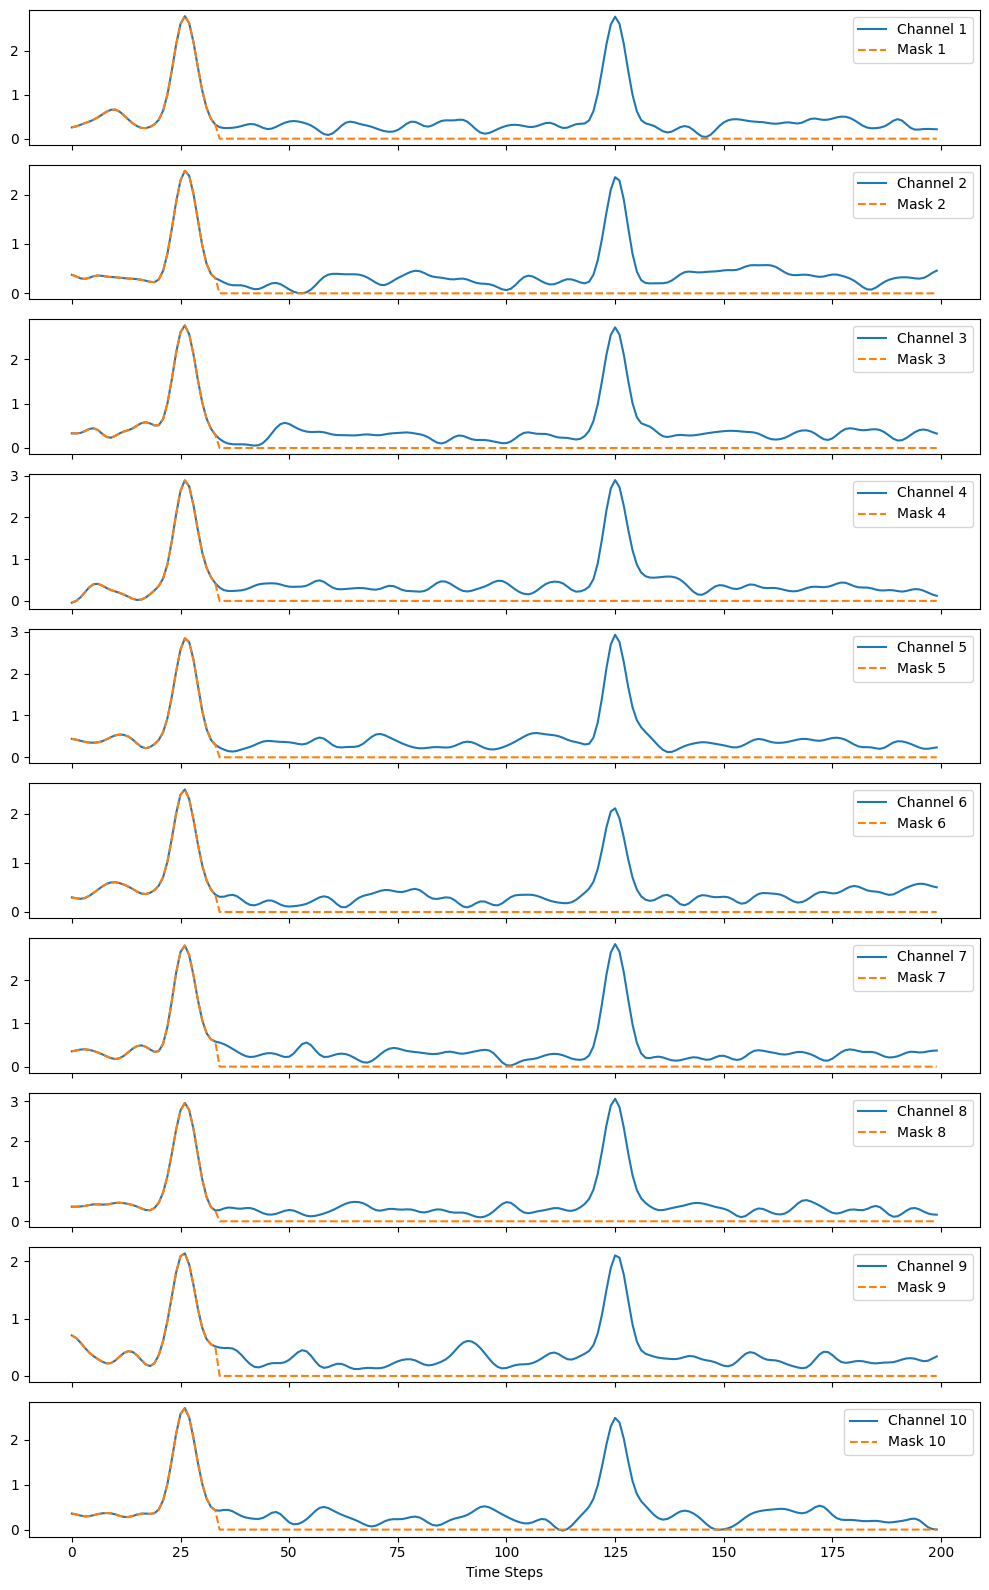

In [10]:
# Plot a few channels in one trial
fig, axes = plt.subplots(10, 1, figsize=(10, 16), sharex=True)
for i in range(10):
    axes[i].plot(EVs[1, :, i], label=f'Channel {i+1}')
    axes[i].plot(mask_EVs[1, :, i], label=f'Mask {i+1}', linestyle='--')
    axes[i].legend()
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [ ]:
labels = EVs.copy()
inputs = mask_EVs.copy()

# # Mask the inputs
# from rtgym.utils.masking import Masking
# mask = Masking(
#                 m_max=0.4,    # Maximum masking ratio
#                 m_min=0.3,    # Minimum masking ratio
#                 sigma_t=1.0,  # Temporal smoothing
#                 sigma_d=1.0,  # Spatial smoothing
#                 t_warmup=0,  # Number of initial time steps to remain unmasked
#                 # device=torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
#                 )
# inputs = mask.mask(inputs).numpy()

inputs = torch.tensor(inputs, dtype=torch.float32).to(device)
labels = torch.tensor(labels, dtype=torch.float32).to(device)

In [ ]:
# fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
# for i in range(5):
#     axes[i].imshow(inputs[i].T.cpu().numpy(), aspect='auto', cmap='hot', interpolation='nearest')
#     axes[i].set_ylabel('Channels')
# plt.xlabel('Time Steps')
# plt.tight_layout()
# plt.show()

## Train the RNN

In [ ]:
# # Plot a few test trials
# fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
# plot_idx = 40
# for i in range(5):
#     axes[i].plot(inputs[plot_idx, :, i].cpu().numpy(), color='C0',label=f'Prediction')
#     axes[i].plot(labels[plot_idx, :, i].cpu().numpy(), color='C1', linestyle='--', label='Target')
#     axes[i].legend()
# plt.xlabel('Time Steps')
# plt.tight_layout()
# plt.show()

In [ ]:
num_neuron = 512

model_cfg = {
            "input_dim":    inputs.shape[2],
            "hidden_dim":   num_neuron,
            'output_dim':   inputs.shape[2],
            "alpha":        0.03,
            "learn_alpha":  False,
            "preact_noise": 0.3,
            "postact_noise":0.5
            }


rnn = nn4n.nn.RNN(
      # Input laters (multiple recurrent layers)
      recurrent_layers=[# 1st recurrent layer
                        nn4n.nn.RecurrentLayer(
                        projection_layer=nn4n.nn.LinearLayer(
                                         input_dim=model_cfg["input_dim"],
                                         output_dim=model_cfg["hidden_dim"]
                                         ),
                        leaky_layer=nn4n.nn.LeakyLinearLayer(
                                    # input_dim=model_cfg["hidden_dim"],
                                    # output_dim=model_cfg["hidden_dim"],
                                    # ----------------------------------------
                                    linear_layer=nn4n.nn.LinearLayer(
                                        input_dim=model_cfg["hidden_dim"],
                                        output_dim=model_cfg["hidden_dim"]),
                                    # ----------------------------------------
                                    activation=torch.nn.ReLU(),
                                    alpha=model_cfg["alpha"],
                                    learn_alpha=model_cfg["learn_alpha"],
                                    preact_noise=model_cfg["preact_noise"],
                                    postact_noise=model_cfg["postact_noise"]
                                    )
                        )
                        # 2nd recurrent layer (None)
                        ],
      # Output layer
      readout_layer=nn4n.nn.LinearLayer(
                    input_dim=model_cfg["hidden_dim"],
                    output_dim=model_cfg["output_dim"]
                    )
      )
rnn.to(device)


def custom_loss(recon, target, firing_rates, lambda_mse, lambda_r):
    """
    Args:
        recon: [batch, time, dim] — reconstructed experience vectors (ŷ)
        target: [batch, time, dim] — ground truth experience vectors (y)
        firing_rates: [batch, time, N] — firing rates of all hidden neurons
    """

    # Shape values
    B, T, D = target.shape
    N = firing_rates[0].shape[2]

    # 1. Reconstruction MSE Loss
    mse = torch.sum((recon - target) ** 2) / (B * T * D)
    # mse = torch.nn.MSELoss()
    # mse = mse(recon, target)

    # 2. Firing rate regularization term
    reg = torch.sum(torch.sum(firing_rates[0], axis=(0,1))**2 / (B * T)) / N

    total_loss = lambda_mse * mse + lambda_r * reg
    # print(lambda_mse * mse, lambda_r * reg)
    return total_loss, lambda_mse * mse, lambda_r * reg


optimizer = torch.optim.Adam(rnn.parameters(), lr=0.0005) 

In [ ]:
# Create DataLoader for training and testing
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(inputs, labels)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

In [ ]:
from tqdm import tqdm

rnn.train()

losses = []

for epoch in tqdm(range(20000)):

    for batch_inputs, batch_labels in train_loader:
        
        optimizer.zero_grad()
        batch_outputs, batch_hidden = rnn(batch_inputs)
        
        # loss = criterion(batch_outputs, batch_labels)
        loss, loss1, loss2 = custom_loss(batch_outputs, batch_labels, batch_hidden, lambda_mse=1, lambda_r=0.0001
                           ) 
        loss.backward()
        
        optimizer.step()
        losses.append(loss.item())
        
    if epoch % 500 == 0:
        print(f'Epoch {epoch} Loss {loss.item()}')
        print(loss1, loss2)
    if  losses[-1] < 0.01 and abs(losses[-1] - losses[-50]) < 1e-4: # len(losses) > 50  :
        print("Early stopping due to convergence.")
        break
    
print("Training complete.")

In [ ]:
plt.figure()
plt.plot(losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')  
plt.tight_layout()

Test the model

In [ ]:
# Generate 64 test trials
test_idx = np.random.randint(0, ntrial, size=64)
test_inputs = inputs[test_idx]
test_labels = labels[test_idx]

In [ ]:
rnn.eval()
with torch.no_grad():
    test_outputs_from_RNN, hidden_states_from_RNN = rnn(test_inputs)

test_outputs = test_outputs_from_RNN.cpu().numpy()
hidden_states = hidden_states_from_RNN[0].cpu().numpy()
print('test outputs:',  test_outputs.shape)
print('hidden states:', hidden_states.shape)

In [ ]:
# Plot a few test trials
fig, axes = plt.subplots(5, 1, figsize=(5, 8), sharex=True)
plot_idx = 40
for i in range(5):
    axes[i].plot(test_outputs[plot_idx, :, i], color='C0',label=f'Prediction')
    axes[i].plot(test_labels[plot_idx, :, i].cpu().numpy(), color='C1', linestyle='--', label='Target')
    axes[i].legend()
plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [ ]:
def plt_hs(hs, min_fr=0.1, fig=None, ax=None):

    time_points, num_neurons = hs.shape[0], hs.shape[1]

    # Select neurons with mean firing rate > 0.1
    mean_fr = hs.mean(axis=0)
    # Get the index where mean_fr > min_fr
    mask = mean_fr > min_fr
    neuron_indices = np.where(mask)[0]
    select_hs = hs[:, neuron_indices]
    del hs

    # Normalize the hs along time points (Sure to be correct!)
    # norm_hs = select_hs / np.linalg.norm(select_hs, axis=0, keepdims=True)
    # 0-1 Normalise method 2
    norm_hs = np.zeros_like(select_hs)
    for n in range(select_hs.shape[1]):
        norm_hs[:, n] = (select_hs[:, n]-np.min(select_hs[:, n]))/(np.max(select_hs[:, n])-np.min(select_hs[:, n]))
    del select_hs
    
    # Sort neurons from maximum firing time
    max_time = np.argmax(norm_hs, axis=0)
    sorted_neuron_indices = np.argsort(max_time)
    norm_hs = norm_hs[:, sorted_neuron_indices]
    
    # Plot the normalized hs
    ax.imshow(norm_hs.T, aspect='auto', cmap='jet',  
              extent=[0, time_points/10, 0, num_neurons]
              )
    # ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neurons')
    ax.set_xticks(np.linspace(0, norm_hs.shape[0]/10, 6))
    
    return norm_hs, fig, ax

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
norm_hs, fig, ax = plt_hs(hidden_states[30], min_fr=0.1, fig=fig, ax=ax)

## Save the data

In [ ]:
save_dict = {}